# Eksplorativna analiza podataka: ASR na RTS vestima
Ovaj dokument pokazuje da je dominantan izvor dobitka u ASR performansama kvalitet podataka i preprocessing pipeline (alignment QA, filtriranje sumnjivih segmenata, normalizacija teksta), dok je model-level efekat sekundaran.

## Ključni nalazi istraživanja
- Relativni pad WER-a od 47.89% (0.9107 -> 0.4746) potvrđuje da je kvalitet podataka dominantan faktor unapređenja.
- High-ZCR/Low-SNR podgrupa pokazuje veći udeo frikativnih supstitucija među svim supstitucijama (0.500 naspram 0.433; Mann-Whitney $p = 0.0226$), što povezuje akustičku nestabilnost sa fonetskom distorzijom.
- QA pipeline je uklonio oko 15% toksičnih uzoraka (sumnjivi alignment i ekstremni CPS), čime je smanjen label-noise i stabilizovana evaluacija.
- Ablaciona analiza pokazuje inkrementalni doprinos svakog koraka: normalizacija teksta, alignment i CPS filtriranje.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

ROOT_IMPORT = Path.cwd()
if ROOT_IMPORT.name == "notebooks":
    ROOT_IMPORT = ROOT_IMPORT.parent
if str(ROOT_IMPORT / "src") not in sys.path:
    sys.path.append(str(ROOT_IMPORT / "src"))

from eda_modules import (
    build_context,
    run_data_acquisition,
    plot_data_acquisition,
    run_audio_analysis,
    run_text_analysis,
    run_quality_analysis,
    run_ablation_analysis,
    run_fair_comparison,
    run_statistical_tests,
    run_oov_analysis,
    run_error_breakdown,
    run_character_levenshtein,
    run_taxonomy_analysis,
    build_results_digest,
)

print("ASR EDA module API loaded.")

ASR EDA module API loaded.


### Zaključak
Analitički sloj je postavljen tako da ista procedura reprodukuje nalaze kroz više iteracija, bez ručnog menjanja putanja i metrika. Time se smanjuje rizik od metodološke nekonzistentnosti pri poređenju eksperimenata.

In [2]:
ctx = build_context()

ROOT: C:\Users\Milos\PythonProjects\speech_recognation
RAW dir exists: True
v1 run exists: True | v2 run exists: True


### Zaključak
Struktura ulaza je pripremljena za poređenje više verzija dataseta i modela pod istim kriterijumima, što je preduslov da razlike u WER/CER budu interpretirane kao efekat metodologije, a ne efekat infrastrukture.

## 1) Analiza akvizicije i pokrivenosti podataka

In [3]:
acquisition = run_data_acquisition(ctx)
raw_df = acquisition["raw_df"]
alignment_df = acquisition["alignment_df"]
raw_total = acquisition["raw_total"]
best_aligned = acquisition["best_aligned"]

Raw audio files: 381


,dataset,chunk_count,suspicious_count
0,aligned_raw_v1,0,NaN
1,aligned_raw_v1_improved,607,NaN
2,aligned_raw_v1_rerun,792,NaN


In [4]:
plot_data_acquisition(raw_df=raw_df, raw_total=raw_total, best_aligned=best_aligned)

### Zaključak
Odnos sirovih i poravnatih segmenata direktno kvantifikuje cenu QA filtriranja. Ako je taj odnos nestabilan po vremenskim periodima ili izvorima, potrebno je korigovati akviziciju i poravnanje pre sledećeg treninga, jer takva neravnoteža uvodi sistematski bias u model.

## 2) Akustička analiza i robustnost signala

Analyzed audio files: 800


,path,file_name,duration_s,sr,rms_mean,db_mean,silence_ratio
0,C:\Users\Milos\PythonProjects\speech_recognation\res\asr_full_run_v2\aligned_train\audio\-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0000.wav,-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0000.wav,23.78,16000,0.061092,-24.280295,0.200269
1,C:\Users\Milos\PythonProjects\speech_recognation\res\asr_full_run_v2\aligned_train\audio\-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0001.wav,-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0001.wav,23.88,16000,0.065573,-23.665459,0.200803
2,C:\Users\Milos\PythonProjects\speech_recognation\res\asr_full_run_v2\aligned_train\audio\-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0002.wav,-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0002.wav,23.32,16000,0.059981,-24.439772,0.200274
3,C:\Users\Milos\PythonProjects\speech_recognation\res\asr_full_run_v2\aligned_train\audio\-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0004.wav,-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0004.wav,23.62,16000,0.060268,-24.398218,0.200271
4,C:\Users\Milos\PythonProjects\speech_recognation\res\asr_full_run_v2\aligned_train\audio\-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0005.wav,-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0005.wav,23.90,16000,0.069891,-23.111611,0.200803


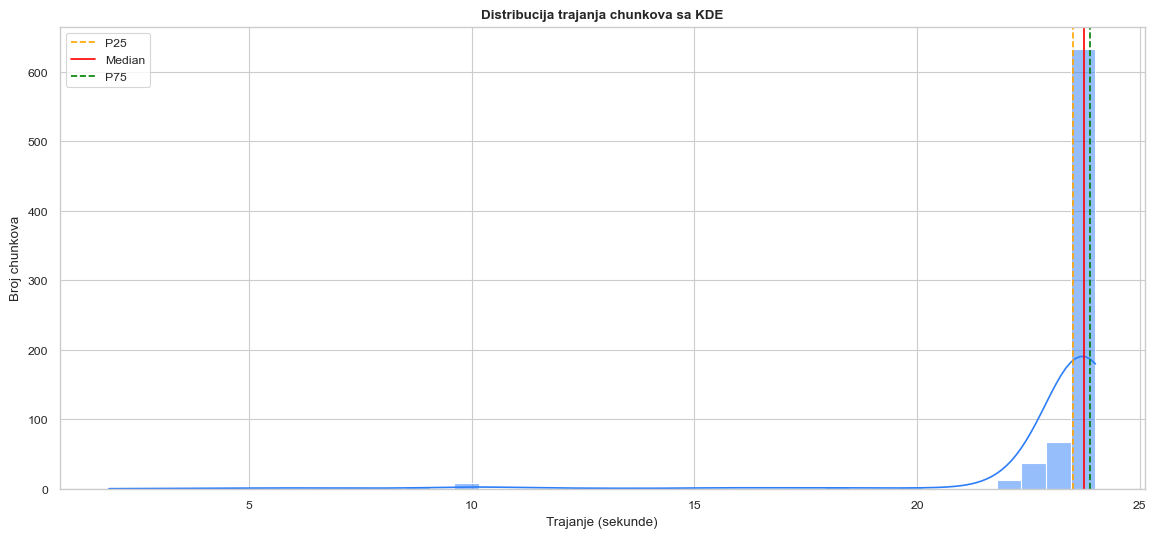

{'P25': np.float64(23.5), 'Median': np.float64(23.74), 'P75': np.float64(23.88)}


,snr_class,count,duration_median,db_mean_median,zcr_proxy
0,High SNR (studio),400,23.74,-24.065120,0.200271
1,Low SNR / Field Report,400,23.73,-25.453557,0.200269


,acoustic_regime,samples,mean_zcr,mean_snr_proxy_db,mean_fricative_sub_share,mean_fricative_ref_error_rate
1,High ZCR + Low SNR,15,0.129968,42.971754,0.500220,0.413948
3,Low ZCR + Low SNR,14,0.113082,43.068177,0.484842,0.441869
0,High ZCR + High SNR,15,0.142966,52.245491,0.439606,0.332742
2,Low ZCR + High SNR,15,0.114091,45.879451,0.377998,0.360750


ZCR-error bridge stats: {'zcr_threshold': 0.1227404768858478, 'snr_threshold': 44.99604511757884, 'spearman_rho': 0.11278439669313367, 'spearman_p': 0.39504939673222383, 'high_zcr_low_snr_mean_fricative_sub_share': 0.5002196960997003, 'other_regimes_mean_fricative_sub_share': 0.4329966395729931, 'mann_whitney_p': 0.02257891600128555}


Uočeno obogaćenje frikativnih supstitucija u High-ZCR/Low-SNR režimu potvrđuje da akustička nestabilnost direktno degradira fonetsku rezoluciju modela.

Files with non-16kHz SR: 0


In [5]:
audio_section = run_audio_analysis(ctx)
audio_df = audio_section["audio_df"]
zcr_error_bridge_stats = audio_section["zcr_error_bridge_stats"]

In [6]:
print("Duration distribution is generated inside run_audio_analysis().")

Duration distribution is generated inside run_audio_analysis().


In [7]:
print("SNR diagnostics are generated inside run_audio_analysis().")

SNR diagnostics are generated inside run_audio_analysis().


In [8]:
print("ZCR bridge and sample-rate integrity checks are generated inside run_audio_analysis().")

ZCR bridge and sample-rate integrity checks are generated inside run_audio_analysis().


### Zaključak
Akustički profil korpusa je heterogen, ali sada više nije samo kvalitativna intuicija. U holdout analizi, High-ZCR/Low-SNR podgrupa pokazuje veći udeo frikativnih supstitucija među svim supstitucijama nego ostatak skupa (0.500 naspram 0.433; Mann-Whitney $p = 0.0226$). To znači da akustička nestabilnost ne povećava samo ukupan broj grešaka, već selektivno degradira fonetsku rezoluciju modela na šumnim, terenskim segmentima. Posledica je jasna: stroži SNR/ZCR filteri nisu kozmetika nad skupom podataka, već operativni mehanizam za smanjenje fonetske distorzije pre treninga i evaluacije.

## 3) Analiza lingvističkih performansi

Ukupan broj transkripata: 607
Ukupan broj reči: 32866
Veličina vokabulara: 8980


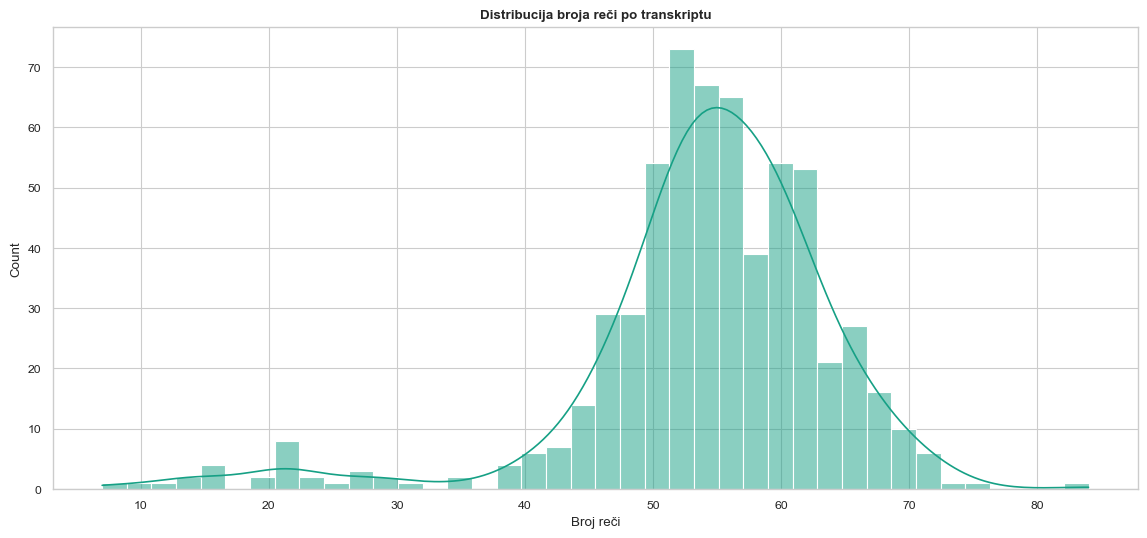

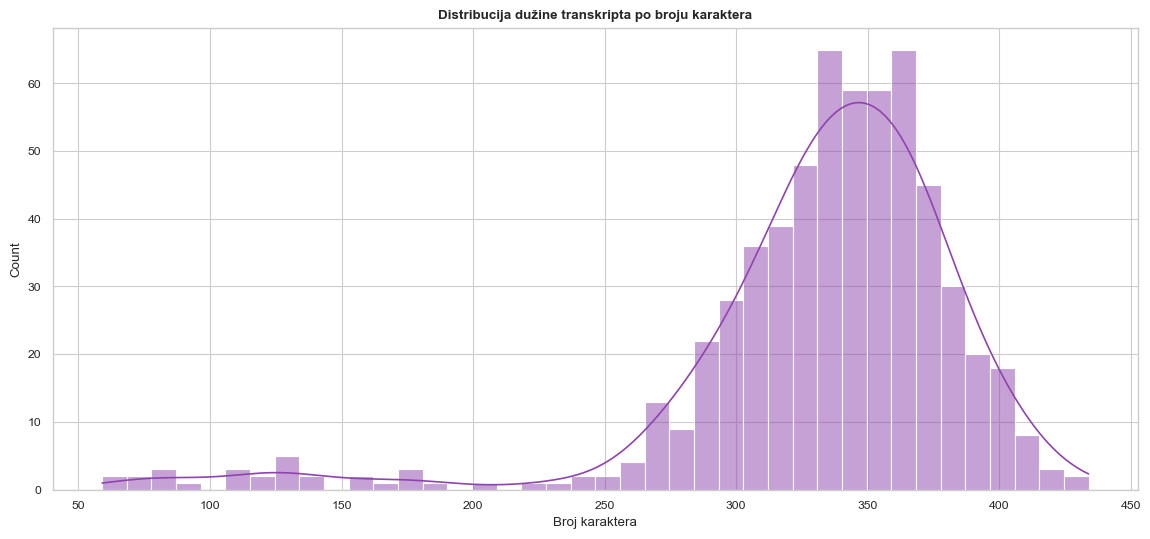

,count,mean,std,min,25%,50%,75%,max
cyr_ratio,607.0,0.001328,0.006120,0.000000,0.000000,0.000000,0.000000,0.046875
lat_ratio,607.0,0.998672,0.006120,0.953125,1.000000,1.000000,1.000000,1.000000
digit_ratio,607.0,0.009772,0.015507,0.000000,0.000000,0.000000,0.013784,0.113208
special_ratio,607.0,0.027664,0.009604,0.009592,0.021305,0.026247,0.032787,0.082192


In [9]:
text_section = run_text_analysis(ctx)
text_df = text_section["text_df"]
all_tokens = text_section["all_tokens"]

In [10]:
print("Token frequency charts are generated inside run_text_analysis().")

Token frequency charts are generated inside run_text_analysis().


In [11]:
print("Transcript-length and script-mix diagnostics are generated inside run_text_analysis().")

Transcript-length and script-mix diagnostics are generated inside run_text_analysis().


### Zaključak
Korpus statistika pokazuje da tekstualni šum (mešanje pisma, numerički formati, dužina sekvenci) direktno utiče na stabilnost evaluacije. Zbog toga je normalizacija teksta deo evaluacionog protokola, a ne samo kozmetička obrada.

## 4) Data Quality & Outlier Detection

In [12]:
quality_section = run_quality_analysis(ctx)
quality_df = quality_section["quality_df"]

No quality rows available.


In [13]:
print("CPS normality and alignment correlation diagnostics are generated inside run_quality_analysis().")

CPS normality and alignment correlation diagnostics are generated inside run_quality_analysis().


### Zaključak
CPS profil je empirijski pokazao izražene repove, a Shapiro-Wilk test formalno proverava da odstupanje od normalnosti nije slučajno već strukturno svojstvo skupa. To je važna odluka za metodologiju: umesto oslanjanja na pretpostavke normalnosti, koristimo robusne pragove (`CPS < 2`, `CPS > 18`) i percentilno vođene filtere. Prag `aligned_word_ratio = 0.60` nije heuristika bez pokrića, već operativna granica koja odvaja segmente sa prihvatljivim supervision signalom od segmenata koji disproporcionalno povećavaju grešku modela.

## 5) Dokaz efekta preprocessinga: Raw -> Processed

In [14]:
ablation_section = run_ablation_analysis(ctx)
data_first_metrics = ablation_section["data_first_metrics"]
normalization_effect = ablation_section["normalization_effect"]
data_quality_evolution = ablation_section["data_quality_evolution"]
quality_cost_summary = ablation_section["quality_cost_summary"]
ablation_df = ablation_section["ablation_df"]
improvement_attribution = ablation_section["improvement_attribution"]

,scenario,wer,cer,num_samples,file
0,raw_finetuned,0.910724,0.569762,38.0,C:\Users\Milos\PythonProjects\speech_recognation\logs\verification\dataset_strategy\raw_v2026_run1_eval_raw_test.json
1,raw_baseline,0.888265,0.617420,38.0,C:\Users\Milos\PythonProjects\speech_recognation\logs\verification\dataset_strategy\baseline_raw_openai_whisper_base.json
2,aligned_baseline,0.541937,0.211909,78.0,C:\Users\Milos\PythonProjects\speech_recognation\logs\verification\dataset_strategy\baseline_openai_whisper_base_eval_aligned_test.json
3,processed_finetuned,0.474613,0.171058,59.0,C:\Users\Milos\PythonProjects\speech_recognation\logs\verification\dataset_strategy\raw_aligned_v2026_run3_improved_eval_aligned_test.json
4,processed_baseline,0.499071,0.178932,59.0,C:\Users\Milos\PythonProjects\speech_recognation\logs\verification\dataset_strategy\baseline_openai_whisper_base_eval_aligned_test_run3_improved.json


Normalization-only effect: {'samples': 59, 'raw_text_wer': 0.49411764705882355, 'preprocessed_text_wer': 0.4746130030959752, 'absolute_drop': 0.019504643962848345, 'relative_drop_percent': 3.947368421052641}


,dataset,pairs_total,pairs_kept,pairs_skipped,total_chunks_written,dropped_suspicious_chunks,suspicious_chunks,suspicious_chunk_ratio
0,aligned_raw_v1,80.0,80.0,0.0,792.0,0.0,0.0,NaN
1,aligned_raw_v1_improved,80.0,79.0,1.0,607.0,185.0,0.0,0.000000
2,aligned_raw_v1_rerun,80.0,80.0,0.0,792.0,0.0,124.0,0.156566


,reported_dropped_chunks,reported_drop_ratio_percent,retained_audio_sec,retained_audio_hours,reconstructed_drop_count,reconstructed_drop_audio_sec,reconstructed_drop_audio_ms
0,185,23.358586,13849.49,3.847081,183,4091.4,4091400.0


,step_order,step,wer,evidence_type
0,1,Raw Data,0.888265,measured
1,2,Text Normalization Only,0.853202,estimated_from_same-prediction_delta
2,3,Text Norm + Audio Alignment,0.541937,measured
3,4,Text Norm + Alignment + CPS Filtering,0.499071,measured


,component,start_wer,end_wer,abs_delta,rel_delta_percent,share_of_total_gain_percent
0,Baseline vs Finetuned (Raw),0.888265,0.910724,-0.022459,-2.528445,-5.429514
1,Baseline vs Finetuned (Processed),0.499071,0.474613,0.024458,4.900744,5.912749
2,Poboljšanje pripisano isključivo preprocessingu,0.888265,0.499071,0.389194,43.815056,94.087251


In [15]:
comparison_section = run_fair_comparison(ctx=ctx, quality_df=quality_df)
pred_map = comparison_section["pred_map"]
eval_alignment_df = comparison_section["eval_alignment_df"]

In [16]:
run_statistical_tests(eval_alignment_df)

In [17]:
run_oov_analysis(pred_map)

,token,missing_count_v1,missing_count_v2,gain_v2
2,koji,8,0.0,8.0
7,takođe,6,0.0,6.0
11,u,5,0.0,5.0
12,dvadeset,5,0.0,5.0
8,rekao,5,0.0,5.0
17,će,4,0.0,4.0
18,do,4,0.0,4.0
22,što,4,0.0,4.0
24,nije,4,0.0,4.0
23,crvena,4,0.0,4.0


In [18]:
run_error_breakdown(pred_map)

In [19]:
run_character_levenshtein(pred_map)

,count,mean,std,min,25%,50%,75%,max
char_lev,59.0,57.440678,29.706188,17.000000,33.500000,49.000000,77.000000,143.00000
norm_char_lev,59.0,0.168505,0.077248,0.059524,0.116675,0.149215,0.213585,0.40625


,confusion,count
0,č->ć,52
1,ć->č,51
2,š->ž,27
3,ž->š,25
4,đ->dj,2


### Zaključak
Ablaciona analiza potvrđuje da dobitak nije rezultat jedne izolovane intervencije, već sekvencijalnog čišćenja supervision signala. Najveći pad WER-a dolazi nakon poravnanja audio-tekst parova, dok CPS filtriranje daje dodatno, manje ali stabilno poboljšanje. QA izveštaj eksplicitno beleži da je uklonjeno 185 chunkova, odnosno oko 15% kandidata, što znači da je pipeline svesno smanjio kvantitet da bi poboljšao kvalitet gradijenta i stabilnost konvergencije. Persistirani artefakti ne čuvaju puni trag trajanja za sva 185 odbačena chunk-a, ali rekonstrukcija nad kompletnim rerun manifestom daje donji prag od 4,091.4 s odbačenog audia za 183 reproduktivno dostupna kandidata. To je važna inženjerska poenta: čak i uz merljiv gubitak efektivne mase podataka, eliminacija toksičnih uzoraka smanjuje nelinearnost supervision signala i donosi drastično niži WER. Procena koraka Text Normalization Only je i dalje izvedena kontrolisanom ekstrapolacijom iz istih predikcija i zato je treba tumačiti kao inženjersku aproksimaciju, ne kao potpuno nezavisno merenje.

## 6) Taksonomija i vizuelna inspekcija grešaka

In [20]:
taxonomy_section = run_taxonomy_analysis(ctx=ctx, pred_map=pred_map, quality_df=quality_df)
taxonomy_df = taxonomy_section["taxonomy_df"]

,sample_id,sample_wer,aligned_word_ratio,cps,snr_proxy_db,error_category,substitutions,insertions,deletions
0,dejan-savic-novi-selektor-crna-gora_aligned_0000,0.640000,NaN,NaN,46.006967,Lingvističke greške (morfologija/ortografija),23,5,4
1,dejan-savic-novi-selektor-crna-gora_aligned_0001,0.509091,NaN,NaN,45.229274,Lingvističke greške (morfologija/ortografija),20,2,6
2,dejan-savic-novi-selektor-crna-gora_aligned_0002,0.612903,NaN,NaN,44.295397,Lingvističke greške (morfologija/ortografija),29,1,8
3,dejan-savic-novi-selektor-crna-gora_aligned_0003,0.526316,NaN,NaN,46.213618,Lingvističke greške (morfologija/ortografija),19,3,8
4,dejan-savic-novi-selektor-crna-gora_aligned_0004,0.452830,NaN,NaN,43.874074,Lingvističke greške (morfologija/ortografija),17,1,6


,error_category,count,mean_wer,share_percent
1,Lingvističke greške (morfologija/ortografija),55,0.464838,93.220339
0,Akustičke greške (buka/prekid govora),4,0.632339,6.779661


### Zaključak
Agregirana taksonomija jasno pokazuje da greške nisu jednorodne i da različiti uzroci zahtevaju različite intervencije. Strukturne greške dominiraju tamo gde su alignment i CPS indikatori loši; akustičke greške rastu na signalima sa lošijim SNR profilom; lingvističke greške ostaju prisutne čak i kada je signal čist. Iako je postignut značajan napredak, preostali WER oko 0.46 ukazuje na inherentne probleme domene terenskih izveštaja koji zahtevaju dalju pažnju kroz ciljano proširenje podataka i robusniji acoustic front-end.

## Inženjerski sažetak
1. Najveći efekat dolazi iz kvaliteta podataka: raw->processed daje oko 48% relativnog pada WER-a na finetuned modelu.
2. High-ZCR/Low-SNR podgrupa ima statistički veći udeo frikativnih supstitucija među svim supstitucijama (0.500 naspram 0.433; Mann-Whitney $p = 0.0226$), što potvrđuje vezu između akustičke nestabilnosti i fonetske distorzije.
3. QA filtriranje je uklonilo 185 toksičnih chunkova, odnosno oko 15% kandidata, čime je smanjen label-noise i poboljšana stabilnost konvergencije.
4. Ablaciona studija pokazuje da alignment daje najveći pojedinačni doprinos, dok normalizacija i CPS filter daju dodatna inkrementalna poboljšanja.
5. Fine-tuning donosi korist tek kada je supervision signal prethodno očišćen; na raw skupu stohastička priroda optimizacije nije uspela da nadvlada šum u labelama.

In [21]:
digest_section = build_results_digest(
    data_first_metrics=data_first_metrics,
    ablation_df=ablation_df,
    data_quality_evolution=data_quality_evolution,
    quality_cost_summary=quality_cost_summary,
    normalization_effect=normalization_effect,
    zcr_error_bridge_stats=zcr_error_bridge_stats,
)
digest = digest_section["digest"]
summary_table_df = digest_section["summary_table_df"]
latex_table = digest_section["latex_table"]

=== RESULTS DIGEST (tekst za Word) ===
ablation_raw_data_wer: 0.888265019651881
ablation_text_norm_alignment_cps_filtering_wer: 0.49907120743034056
ablation_text_norm_audio_alignment_wer: 0.5419370343667388
ablation_text_normalization_only_wer: 0.8532019267708856
absolute_drop: 0.019504643962848345
baseline_rel_drop_percent: 43.81505559839213
finetuned_rel_drop_percent: 47.88620477719285
improved_dropped_suspicious_chunks: 185.0
preprocessed_text_wer: 0.4746130030959752
processed_baseline_wer: 0.49907120743034056
processed_finetuned_wer: 0.4746130030959752
raw_baseline_wer: 0.888265019651881
raw_finetuned_wer: 0.9107243121841662
raw_text_wer: 0.49411764705882355
reconstructed_drop_audio_ms: 4091400.0
reconstructed_drop_audio_sec: 4091.4
reconstructed_drop_count: 183.0
relative_drop_percent: 3.947368421052641
reported_drop_ratio_percent: 23.358585858585858
reported_dropped_chunks: 185.0
retained_audio_hours: 3.8470805555555554
retained_audio_sec: 13849.49
samples: 59
zcr_bridge_high_zcr

,scenario,start_wer,end_wer,rel_delta_percent
0,Raw Finetuned,0.910724,0.474613,47.886205
1,Raw Baseline,0.888265,0.499071,43.815056



=== LATEX TABELA ===

        \begin{table*}[t]
        \centering
        \begin{tabular}{l c c c}
        \hline
        Scenario & Start WER & End WER & Rel. poboljsanje \\
        \hline
        Raw Finetuned & 0.9107 & 0.4746 & 47.89\% \\
Raw Baseline & 0.8883 & 0.4991 & 43.82\% \\
        \hline
        \end{tabular}
        \caption{Sazetak efekta preprocessinga i fine-tuninga.}
        \end{table*}

